# CS 282
### Programming Assignment 3

Jan Lendl R. Uy

2019-00312

#### Sytem Specifications
- macOS Sequoia 15.0.1
- Macbook Air M1 (ARM), 8-Core CPU and 8-Core GPU

In [1]:
!pip install -r requirements.txt --quiet


[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cdist

### Step 1
Load the image pair library1_camera, library2_camera, and matching points file library_matches.txt.

In [3]:
# Load images library1 and library2
library_1 = cv2.imread("epipairs/library1.jpg")
library_2 = cv2.imread("epipairs/library2.jpg")

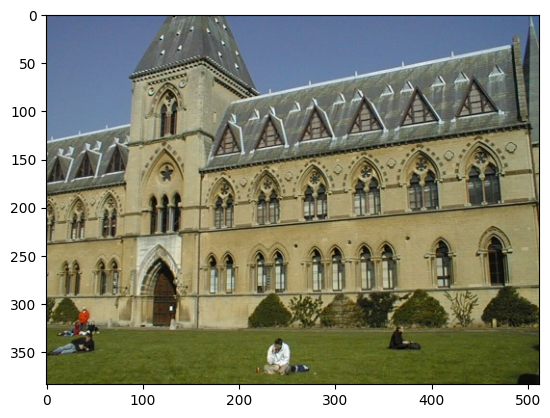

In [4]:
plt.imshow(cv2.cvtColor(library_1, cv2.COLOR_BGR2RGB))

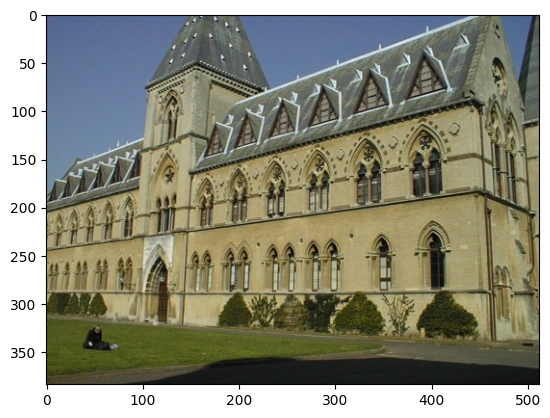

In [5]:
plt.imshow(cv2.cvtColor(library_2, cv2.COLOR_BGR2RGB))

In [6]:
# Load the matches between library1 and library2
matches = np.loadtxt("epipairs/library_matches.txt", dtype=np.float32)

### Step 2
Fit a fundamental matrix to the matching points. There is no need to use RANSAC here since all the
matches are correct. Report the residual, which should be the mean squared distance (in pixels) between points in the second image and the corresponding epipolar lines.

In [7]:
# Get the pair of points in library1 and library2
library_1_points = np.float32(matches[:, 0:2])
library_2_points = np.float32(matches[:, 2:4])

In [8]:
# Fit a fundamental matrix on the two sets of points
F, mask = cv2.findFundamentalMat(library_1_points, library_2_points, cv2.FM_8POINT)
print(f"Fundamental matrix:\n{F}")

Fundamental matrix:
[[ 1.71109778e-07 -3.64743113e-06  5.51941477e-04]
 [ 2.21412150e-05  2.27539906e-07 -4.11109840e-02]
 [-5.28444718e-03  3.69220236e-02  1.00000000e+00]]


In [9]:
# Function for computing the residual
# Mean squared distance between points and the epipolar lines
def compute_residual(points, lines):
    residuals = []
    for i in range(len(points)):
        point = points[i]
        line = lines[i]
        
        # Formula for distance from a point to a line
        # abs(ax + by + c)/sqrt(a^2 + b^2)
        residual = np.abs(line[0, 0] * point[0] + line[0, 1] * point[1] + line[0, 2])/np.sqrt(line[0, 0]**2 + line[0, 1]**2)
        residuals.append(residual)

    mean_residual = np.mean(np.square(residuals))
    
    return mean_residual

In [10]:
# Function to draw epipolar lines for visualization
def draw_epipolar_lines(img1, img2, pts1, pts2, F):
    """Draw epipolar lines and points for visualization"""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Create RGB versions of the images
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        
    # Compute epipolar lines in the second image
    lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F)
    lines2 = lines2.reshape(-1, 3)
    
    # Compute epipolar lines in the first image
    lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2, F)
    lines1 = lines1.reshape(-1, 3)
    
    # Create images with epipolar lines
    img1_lines = img1_rgb.copy()
    img2_lines = img2_rgb.copy()
    
    # Draw epipolar lines and points in the second image
    for i, (pt, line) in enumerate(zip(pts2, lines2)):
        # Choose a random color for the epipole and the epipolar line
        color = np.random.randint(0, 255, 3).tolist()
        x0, y0 = 0, int(-(line[2]) / line[1])
        x1, y1 = w2, int(-(line[2] + line[0] * w2) / line[1])
        
        img2_lines = cv2.line(img2_lines, (x0, y0), (x1, y1), color, 1)
        img2_lines = cv2.circle(img2_lines, (int(pt[0]), int(pt[1])), 5, color, -1)
    
    # Draw epipolar lines and points in the first image
    for i, (pt, line) in enumerate(zip(pts1, lines1)):
        color = np.random.randint(0, 255, 3).tolist()
        x0, y0 = 0, int(-(line[2]) / line[1])
        x1, y1 = w1, int(-(line[2] + line[0] * w1) / line[1])
        
        img1_lines = cv2.line(img1_lines, (x0, y0), (x1, y1), color, 1)
        img1_lines = cv2.circle(img1_lines, (int(pt[0]), int(pt[1])), 5, color, -1)
    
    # Display the images side by side
    plt.figure(figsize=(16, 8))
    plt.subplot(121)
    plt.imshow(img1_lines)
    plt.title("Library 1 with Epipolar Lines")
    
    plt.subplot(122)
    plt.imshow(img2_lines)
    plt.title("Library 2 with Epipolar Lines")
    
    plt.tight_layout()
    plt.show()

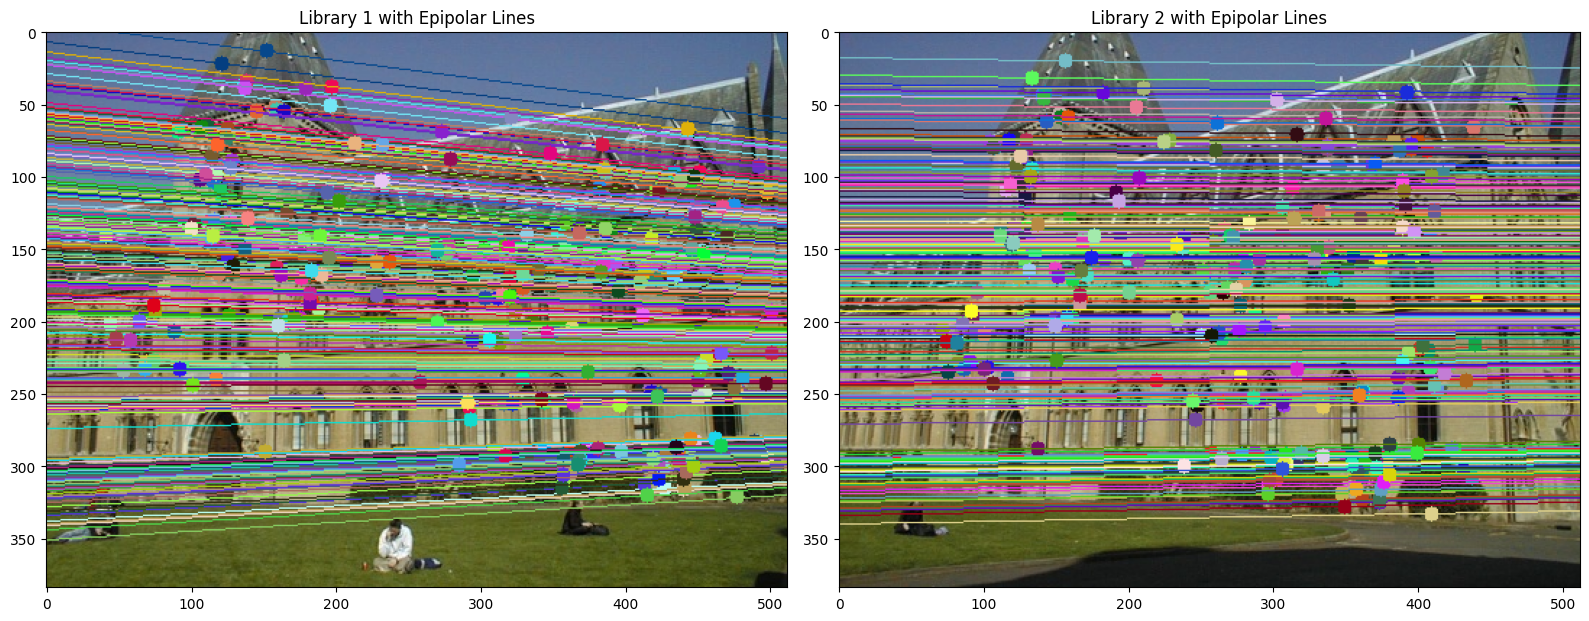

In [11]:
# Visualize epipolar lines in both images
draw_epipolar_lines(library_1, library_2, library_1_points, library_2_points, F)

In [12]:
epipolar_lines_1 = cv2.computeCorrespondEpilines(library_2_points.reshape(-1, 1, 2), 2, F)

mean_residual = compute_residual(library_2_points, epipolar_lines_1)
print(f"Residual = {mean_residual:.5f} pixels")

Residual = 37.15258 pixels


### Step 3
Now fit a fundamental matrix based on putative correspondences obtained by your code from Programming Assignment 2. Because the set of putative matches includes outliers, you will need to use RANSAC. For this part, use only the normalized fitting approach.

In [13]:
# Convert to float
library_1_float = cv2.convertScaleAbs(library_1, cv2.CV_64F)
library_1_gray_uint8 = cv2.cvtColor(library_1_float, cv2.COLOR_BGR2GRAY)
library_2_float = cv2.convertScaleAbs(library_2, cv2.CV_64F)
library_2_gray_uint8 = cv2.cvtColor(library_2_float, cv2.COLOR_BGR2GRAY)

#### Code blocks below are from PA2 for getting putative correspondences

In [14]:
# Library 1

# Get Harris response with parameters:
# blockSize=2
# ksize=3
# k=0.04
response_library_1 = cv2.cornerHarris(
    library_1_gray_uint8, 
    blockSize=2,
    ksize=3,
    k=0.04
)

# Perform thresholding at 1% of max value of the Harris response
threshold_ratio = 0.01
threshold_library_1 = threshold_ratio * response_library_1.max()
corners_library_1 = np.where(response_library_1 > threshold_library_1)
corners_library_1 = np.array(list(zip(corners_library_1[1], corners_library_1[0])))  # (x, y) format

In [15]:
# Library 2

# Get Harris response with parameters:
# blockSize=2
# ksize=3
# k=0.04
response_library_2 = cv2.cornerHarris(
    library_2_gray_uint8, 
    blockSize=2,
    ksize=3,
    k=0.04
)

# Perform thresholding at 1% of max value of the Harris response
threshold_ratio = 0.01
threshold_library_2 = threshold_ratio * response_library_2.max()
corners_library_2 = np.where(response_library_2 > threshold_library_2)
corners_library_2 = np.array(list(zip(corners_library_2[1], corners_library_2[0])))  # (x, y) format

In [16]:
# A patch size of 11x11 resulted in the best inlier points in 
# the succeeding steps
patch_size = 11
half_size = patch_size // 2
h_lib_1, w_lib_1 = library_1_gray_uint8.shape
h_lib_2, w_lib_2 = library_2_gray_uint8.shape

In [17]:
# Extract descriptors for library1
descriptors_library_1 = []
valid_corners_library_1 = []
for x, y in corners_library_1:
    # Check if patch is fully within the image
    if (x - half_size >= 0 and x + half_size < w_lib_1 and
        y - half_size >= 0 and y + half_size < h_lib_1):
        # Extract the patch
        patch = library_1_gray_uint8[y - half_size:y + half_size + 1, 
                           x - half_size:x + half_size + 1]
        
        # Flatten the patch to create a descriptor
        descriptor = patch.flatten()
        
        # Add to the list
        descriptors_library_1.append(descriptor)
        valid_corners_library_1.append((x, y))

# Convert to numpy arrays
descriptors_library_1 = np.array(descriptors_library_1)
valid_corners_library_1 = np.array(valid_corners_library_1)

In [18]:
# Extract descriptors for library2
descriptors_library_2 = []
valid_corners_library_2 = []
for x, y in corners_library_2:
    # Check if patch is fully within the image
    if (x - half_size >= 0 and x + half_size < w_lib_1 and
        y - half_size >= 0 and y + half_size < h_lib_1):
        # Extract the patch
        patch = library_2_gray_uint8[y - half_size:y + half_size + 1, 
                           x - half_size:x + half_size + 1]
        
        # Flatten the patch to create a descriptor
        descriptor = patch.flatten()
        
        # Add to the list
        descriptors_library_2.append(descriptor)
        valid_corners_library_2.append((x, y))

# Convert to numpy arrays
descriptors_library_2 = np.array(descriptors_library_2)
valid_corners_library_2 = np.array(valid_corners_library_2)

In [19]:
# Get the Euclidean distaces between the descriptors of the two images
distances = cdist(descriptors_library_1, descriptors_library_2, "euclidean")

In [20]:
# Select the putative matches using a distance threshold of 200
# 200 was empirically obtained to achieve the best set of inlier matches
# post-reconstruction
distance_threshold = 200
matches = []
for i in range(len(descriptors_library_1)):
    for j in range(len(descriptors_library_2)):
        if distances[i, j] < distance_threshold:
            # Create a cv2.DMatch object instead of a tuple
            match = cv2.DMatch(_queryIdx=i, _trainIdx=j, _distance=distances[i, j])
            matches.append(match)

print(f"Number of matches: {len(matches)}")

Number of matches: 1472


In [21]:
# Convert matches to lists of points
src_pts = np.float32([valid_corners_library_1[m.queryIdx] for m in matches])
dst_pts = np.float32([valid_corners_library_2[m.trainIdx] for m in matches])

In [22]:
# Compute fundamental matrix with RANSAC
F_ransac, mask_ransac = cv2.findFundamentalMat(src_pts, dst_pts, cv2.FM_RANSAC, 1.0, 0.99)

# Get inlier points from the putative sets (src_pts, dst_pts)
inlier_pts1 = src_pts[mask_ransac.ravel() == 1]
inlier_pts2 = dst_pts[mask_ransac.ravel() == 1]

print(f"Fundamental matrix of putative correspondences:\n{F_ransac}")

Fundamental matrix of putative correspondences:
[[ 6.87654509e-07  3.92172320e-05 -1.11393549e-02]
 [-1.92894857e-05  2.74923590e-06 -1.36273422e-02]
 [ 5.55992142e-03  9.10942749e-03  1.00000000e+00]]


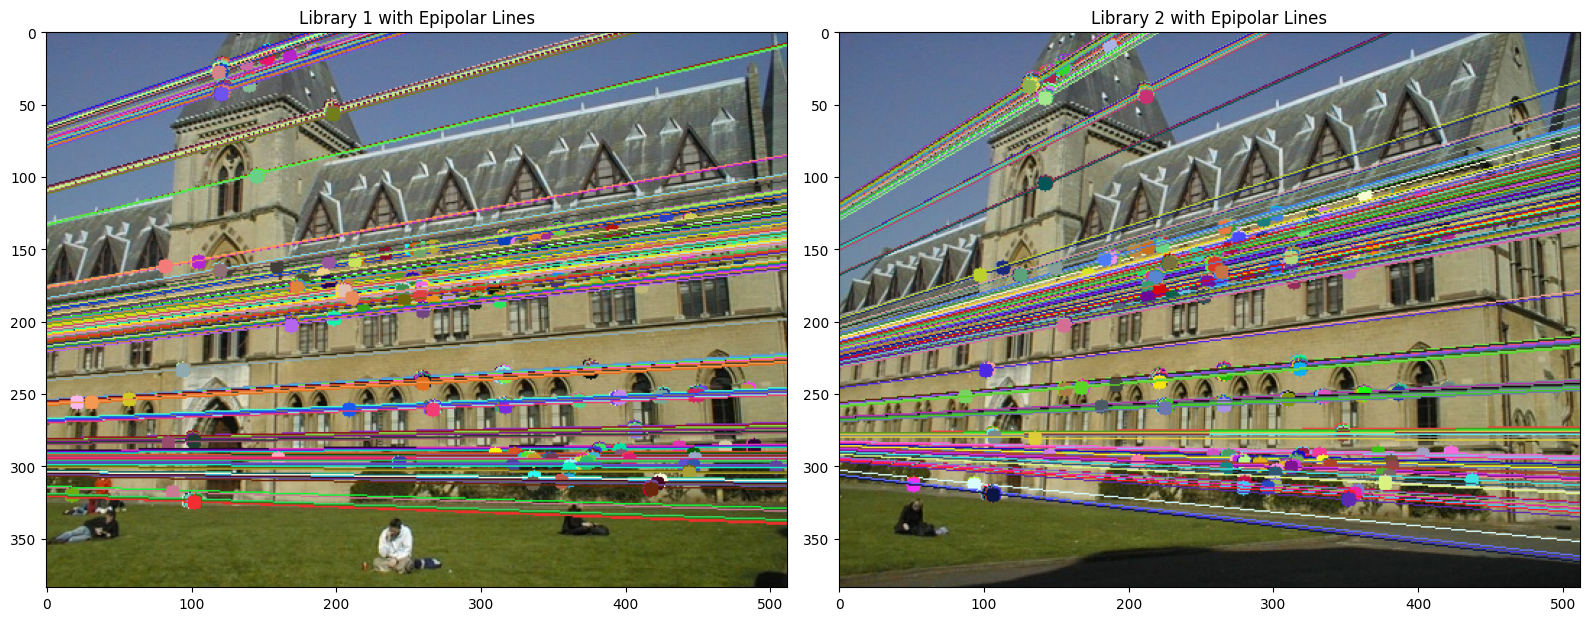

In [23]:
# Visualize epipolar lines in both images
draw_epipolar_lines(library_1, library_2, inlier_pts1, inlier_pts2, F_ransac)

In [ ]:
# Also calculate residual for the inlier points in the 
# second image and corresponding epipolar lines
epipolar_lines_1_ransac = cv2.computeCorrespondEpilines(inlier_pts2.reshape(-1, 1, 2), 2, F_ransac)
residual_ransac = compute_residual(inlier_pts2, epipolar_lines_1_ransac)
print(f"Residual from putative correspondences = {residual_ransac:.5f} pixels")

Residual from putative correspondences = 111.33969 pixels


### Step 4
Load the camera matrices for the two images (they are stored as 3x4 matrices in the files
library1 camera.txt and library2 camera.txt). Find the centers of the two cameras. Use
linear least squares to triangulate the position of each matching pair of points given the two cameras. Display the two camera centers and scene matches in 3D. Also compute the residuals between the observed 2D points and the projected 3D points in the two images.

In [25]:
# Load the camera matrices for library1 and library2
library_1_camera = np.loadtxt("epipairs/library1_camera.txt")
library_2_camera = np.loadtxt("epipairs/library2_camera.txt")

In [26]:
# Function for finding the camera center from a camera matrix P
# The camera center is the null space of P
def find_camera_center(P):
    # Use SVD to find the null space
    U, S, Vt = np.linalg.svd(P)
    
    # The camera center is the last row of Vt
    C_homogeneous = Vt[-1, :]
    
    # Convert from homogeneous coordinates
    C = C_homogeneous[:3] / C_homogeneous[3]
    
    return C

In [27]:
# Obtain the camera centers of the two images
# Use SVD
library_1_center = find_camera_center(library_1_camera)
library_2_center = find_camera_center(library_2_camera)

print(f"Camera 1 Center: {library_1_center}")
print(f"Camera 2 Center: {library_2_center}")

Camera 1 Center: [  7.28863053 -21.52118112  17.73503585]
Camera 2 Center: [  6.89405488 -15.39232716  23.41498687]


In [28]:
# Triangulate the 3D points
points_4d_homogeneous = cv2.triangulatePoints(library_1_camera, 
                                              library_2_camera,
                                              library_1_points.T, 
                                              library_2_points.T)

# Convert from homogeneous coordinates to 3D coordinates
points_3d = points_4d_homogeneous[:3, :] / points_4d_homogeneous[3, :]
points_3d = points_3d.T

In [ ]:
# Function to calculate reprojection error
def calculate_residual_2d_and_3d(P, points_3d, points_2d):
    # Calculate the reprojection error between projected 3D points and original 2D points
    # Convert 3D points to homogeneous coordinates
    points_homogeneous = np.hstack((points_3d, np.ones((points_3d.shape[0], 1))))
    
    # Project 3D points back to 2D
    projected_points = np.dot(P, points_homogeneous.T).T
    projected_points = projected_points[:, :2] / projected_points[:, 2:]
    
    # Calculate Euclidean distance between original and projected points
    errors = np.sqrt(np.sum((projected_points - points_2d)**2, axis=1))
    return errors

In [30]:
# Calculate residual between 2d points and projected 3d points
reprojection_error1 = calculate_residual_2d_and_3d(library_1_camera, points_3d, library_1_points)
reprojection_error2 = calculate_residual_2d_and_3d(library_2_camera, points_3d, library_2_points)

print(f"Mean reprojection error in image 1: {np.mean(reprojection_error1):.5f}")
print(f"Mean reprojection error in image 2: {np.mean(reprojection_error2):.5f}")

Mean reprojection error in image 1: 0.07981
Mean reprojection error in image 2: 0.09272


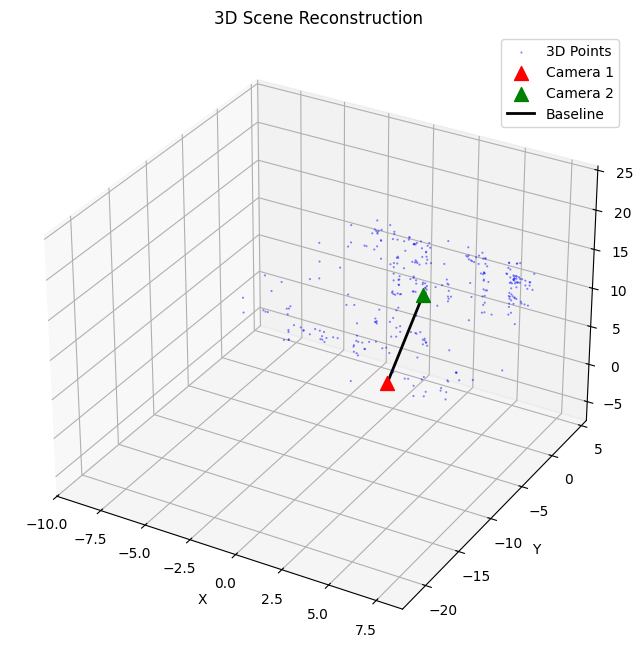

In [31]:
# Visualize the 3D points and camera centers
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot 3D points of scene
ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], 
            c="blue", marker=".", s=1, alpha=0.5, label="3D Points")

# Plot camera centers
ax.scatter(library_1_center[0], library_1_center[1], library_1_center[2], c="red", marker="^", s=100, label="Camera 1")
ax.scatter(library_2_center[0], library_2_center[1], library_2_center[2], c="green", marker="^", s=100, label="Camera 2")

# Connect camera centers (baseline)
ax.plot([library_1_center[0], library_2_center[0]], [library_1_center[1], library_2_center[1]], [library_1_center[2], library_2_center[2]], 
         "k-", linewidth=2, label="Baseline")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Scene Reconstruction")
ax.legend()

plt.show()

### Step 5
Apply triangulation to inlier matches that you obtained in step 3 above.

In [32]:
# Triangulate inlier points
inlier_points_4d = cv2.triangulatePoints(library_1_camera, library_2_camera, inlier_pts1.T, inlier_pts2.T)
inlier_points_3d = inlier_points_4d[:3, :] / inlier_points_4d[3, :]
inlier_points_3d = inlier_points_3d.T

# Calculate residual between 2d points and projected 3d points
# of inlier points
inlier_error1 = calculate_residual_2d_and_3d(library_1_camera, inlier_points_3d, inlier_pts1)
inlier_error2 = calculate_residual_2d_and_3d(library_2_camera, inlier_points_3d, inlier_pts2)

print(f"Mean reprojection error for inliers in image 1: {np.mean(inlier_error1):.5f} pixels")
print(f"Mean reprojection error for inliers in image 2: {np.mean(inlier_error2):.5f} pixels")

Mean reprojection error for inliers in image 1: 1.77673 pixels
Mean reprojection error for inliers in image 2: 1.96742 pixels


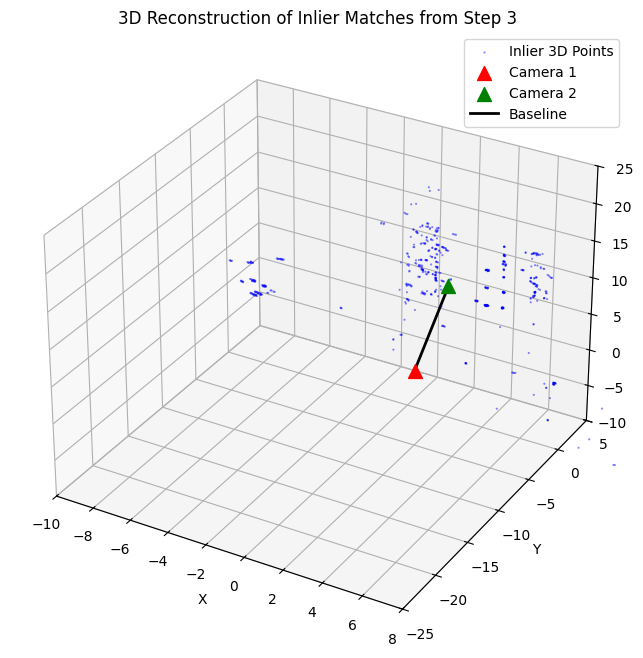

In [33]:
# Visualize the inlier 3D points and camera centers
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot inlier 3D matches
ax.scatter(inlier_points_3d[:, 0], inlier_points_3d[:, 1], inlier_points_3d[:, 2], 
            c="blue", marker=".", s=1, alpha=0.5, label="Inlier 3D Points")

# Plot camera centers
ax.scatter(library_1_center[0], library_1_center[1], library_1_center[2], c="red", marker="^", s=100, label="Camera 1")
ax.scatter(library_2_center[0], library_2_center[1], library_2_center[2], c="green", marker="^", s=100, label="Camera 2")

# Connect camera centers
ax.plot([library_1_center[0], library_2_center[0]], [library_1_center[1], library_2_center[1]], [library_1_center[2], library_2_center[2]], 
         "k-", linewidth=2, label="Baseline")

ax.set_xlabel("X")
ax.set_xlim([-10, 8])
ax.set_ylabel("Y")
ax.set_ylim([-25, 5])
ax.set_zlabel("Z")
ax.set_zlim([-10, 25])
ax.set_title("3D Reconstruction of Inlier Matches from Step 3")
ax.legend()

plt.show()